# **ESERCIZIO 4.1**

**OBIETTIVI**

L'obiettivo dell'esercizio 4.1 è quello di implementare la distribuzione di velocità per un sistema di N particelle e confrontarla con la distribuzione di Maxwell-Boltzmann. In particolare, i parametri di input utilizzati sono:

    SIMULATION_TYPE        0              ovvero simulazione in MD 
    RESTART                0              ovvero imposto la configurazione iniziale "da zero"
    TEMP                   1.9            temperatura iniziale del sistema
    NPART                  108            numero di particelle del mio sistema
    RHO                    0.8            densità del sistema
    R_CUT                  2.5            raggio di cut-off per le interazioni interparticellari
    DELTA                  0.002          passo temporale utilizzato
    NBLOCKS                10             numero di blocchi 
    NSTEPS                 1000           numero di passi per ciascun blocco


**IMPLEMENTAZIONE**

Ho aggiornato il codice di system.cpp aggiungendo la parte relativa alla distribuzione dei moduli delle velocità di Maxwell-Boltzmann in $measure()$, usando le unità ridotte di Lennard Jones (indicate con l'asterisco), ovvero:

$$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}$$

In particolare, utilizzare le unità ridotte LJ significa che:

- Lunghezza ridotta: $$r^* = \frac{r}{\sigma}$$
- Energia ridotta: $$E^* = \frac{E}{\epsilon}$$
- Massa ridotta: $$m^* = \frac{m}{m} = 1$$
- Temperatura ridotta: $$T^* = \frac{k_B T}{\epsilon}$$
- Velocità ridotta: $$v^* = \frac{v}{\sqrt{\epsilon/m}}$$
- Tempo ridotto: $$t^* = t \sqrt{\frac{\epsilon}{m \sigma^2}}$$

Per implementare questa distribuzione, ho calcolato per ogni particella il modulo della sua velocità; dopodichè, ho associato il valore ottenuto al bin corrispondente, al fine di realizzare l'istogramma delle velocità. In particolare, ho realizzato l'istogramma delle velocità non normalizzato (la normalizzazione la farò in averages dopo aver mediato sui blocchi. In questo modo applico la media a blocchi sui conteggi grezzi dell'istogramma. Inoltre, essendo la normalizzazione una divisione per un fattore costante, il risultato finale sarebbe identico anche effettuandola prima della media a blocchi).

Successivamente, ho aggiornato anche il metodo $averages()$ affinchè calcolasse tramite il metodo a blocchi media e errore progressivo anche per la $p(v)$. In particolare, bisogna prestare molta attenzione a come viene impostato il metodo a blocchi, dal momento che devo implementarlo per un istogramma. Quindi, per ogni bin dell'istogramma devo calcolare la media e l'errore tramite il metodo a blocchi: in questo modo, ottengo per ciasun bin il valor medio e l'incertezza del numero di particelle che ricadono in quel bin. Infine, stampo in output per ciascun bin i valori normalizzati, ovvero stampo $p(v)=\frac{<hist(v)>}{N\cdot\Delta v}$, con $N$=numero delle particelle e $\Delta v$=ampiezza del bin in velocità, ottenendo così una densità di probabilità direttamente confrontabile con la distribuzione di MB.

Per quanto riguarda la normalizzazione, devo dividere sia per $N$ sia per $\Delta v$ in quanto mi serve una densità di probabilità: dividendo per N trovo la probabilità discreta di ciascun bin, che però è composto da un intervallo continuo di velocità $\Delta v$, pertanto devo dividere anche per questo valore per poter ottenere la densità di probabilità.

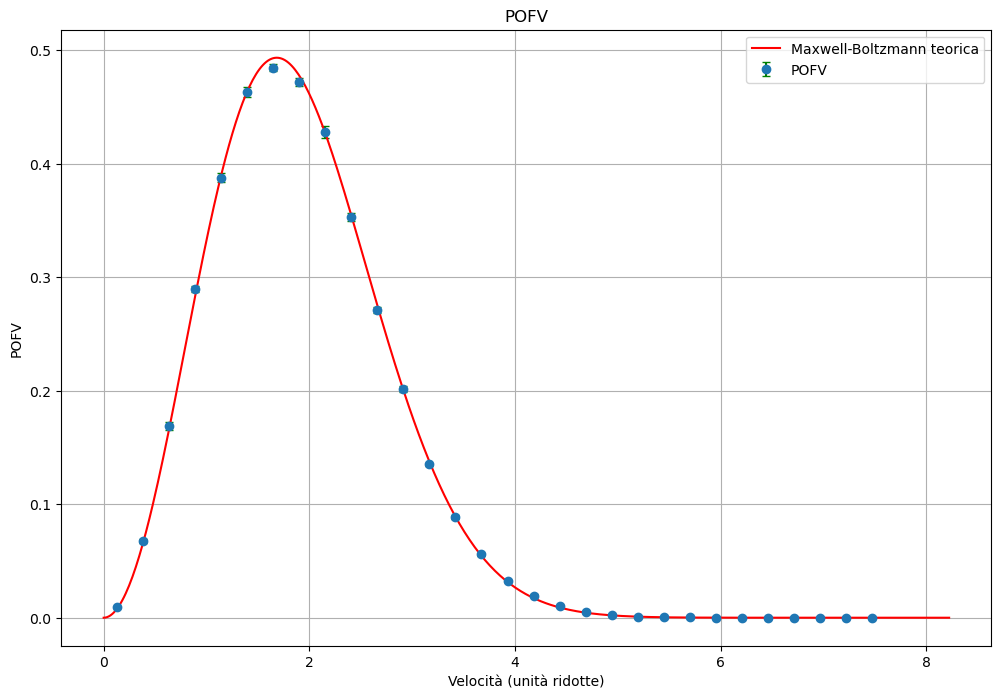

Integrale POFV simulata: 1.000000231057929


In [2]:
import numpy as np
import matplotlib.pyplot as plt

data_pofv=np.loadtxt("NSL_SIMULATOR_4.1/OUTPUT/pofv.dat")

#PARAMETRI ARGON
amu=1.66e-27
sigma=0.34e-9
e_kB=120.0
massa=39.948*amu
kB_value=1.38e-23
eV = 1.602e-19

v_norm=np.sqrt(e_kB*kB_value/massa)

m=1.0
T= 1.41605 #temperatura del blocco finale del file output
kB=1.0


vel=data_pofv[:,0] #velocità del bin associato
media=data_pofv[:,1] #media (metodo a blocchi) di ciacun bin
errore=data_pofv[:,2]  #errore sulla media

#################################################################
# FUNZIONE MAXWELL-BOLTZMANN (teorica)
def MB_teorica(v,m,kB,T):
    const = 4 * np.pi * (m /(2 * np.pi * kB * T)) ** (3/2)
    return const * v**2 * np.exp(-m * v**2 / (2 * kB * T)) #formula MB teorica

v_theory = np.linspace(0, max(vel)*1.1, 500) #genero 500 valori di veloctà tra i due estremi 0 e max_vel*1.1
P_MB = MB_teorica(v_theory, m, kB, T)
#################################################################

plt.figure(figsize=(12,8)) 

plt.errorbar(vel, media, yerr=errore, fmt='o', ecolor='green', capsize=3, label="POFV")

plt.title("POFV")
plt.xlabel("Velocità (unità ridotte)")
plt.ylabel("POFV")

plt.plot(v_theory, P_MB, 'r-', label="Maxwell-Boltzmann teorica")

plt.legend()
plt.grid(True)
plt.show()


integrale = np.sum(media * np.diff(vel, append=vel[-1] + (vel[1]-vel[0])))
print("Integrale POFV simulata:", integrale)

**COMMENTO AI RISULTATI**

Il grafico mostra quello che ci aspettavamo: il sistema, dopo un'oppportuna fase di evoluzione dinamica tramite l’integrazione delle equazioni del moto, perde memoria della condizione iniziale convergendo verso la distribuzione di velocità di Maxwell–Boltzmann. 

I dati ottenuti dalla simulazione (punti blu) risultano infatti quasi tutti compatibili, entro le incertezze statistiche, con la curva teorica di Maxwell–Boltzmann (linea rossa). Questo conferma che l'integrazione delle equazioni del moto e l'inizializzazione delle velocità sono state implementate correttamente e che il sistema ha raggiunto uno stato di equilibrio caratterizzato dalla temperatura assegnata.

Le piccole discrepanze osservabili, in particolare in corrisponenza del massimo della distribuzione, potrebbero essere attribuibili alle fluttuazioni statistiche dovute al numero finito di particelle e di configurazioni campionate durante la simulazione.

# **ESERCIZIO 4.2**

**OBIETTIVI**

L'obiettivo dell'esercizio 4.2 è mostrare che una simulazione MD che parte da uno stato ordinato e non termico raggiunge spontaneamente l’equilibrio termodinamico descritto dalla distribuzione di Maxwell–Boltzmann.

**IMPLEMENTAZIONE**

Preparo il sistema in uno stato a bassissima entropia, molto lontano dall'equilibrio, sia per quanto riguarda le posizioni che le velocità:

- POSIZIONI: creo una configurazione in cui le particelle riempiono un reticolo FCC occupando solo metà di ogni dimensione del box, ovvero $\frac{1}{8}$ del volume totale. In particolare, questo viene fatto impostando nel codice che le configurazioni vengano lette dal file .fcc; successivamente divido per 2 ciasuna coordinata.

- VELOCITA': devo modificare il codice (che altrimenti usa una distribuzione Gaussiana per generare le velocità iniziali) imponendo che ogni particella abbia velocità con modulo fissato. Nello specifico, tutte le particelle devono avere lo stesso modulo della velocità (in unità ridotte, $v^* = \sqrt{3T^*}$), determinato dalla temperatura $T^*$ di input, con direzione (x,y,z) e segno (+,-) assegnati casualmente. In questo modo il sistema presenta inizialmente una distribuzione delle velocità molto lontana da quella di Maxwell–Boltzmann.

- CONVERGENZA VERSO MAXWELL-BOLTZMANN: per mostrare la convergenza della distribuzione delle velocità verso la distribuzione di Maxwell-Boltzmann, confronto $p(v^*, T^*_{\text{eff}})$ con l'istogramma delle velocità misurato a diversi istanti di tempo, 
da $t = 0$ fino a $t = t_{\text{finale}}$, dove $T^*_{\text{eff}}$ è la 
temperatura effettiva del sistema una volta raggiunto l'equilibrio. In questo modo è possibile osservare come una distribuzione inizialmente non termica evolva spontaneamente verso la distribuzione di equilibrio prevista dalla meccanica statistica.

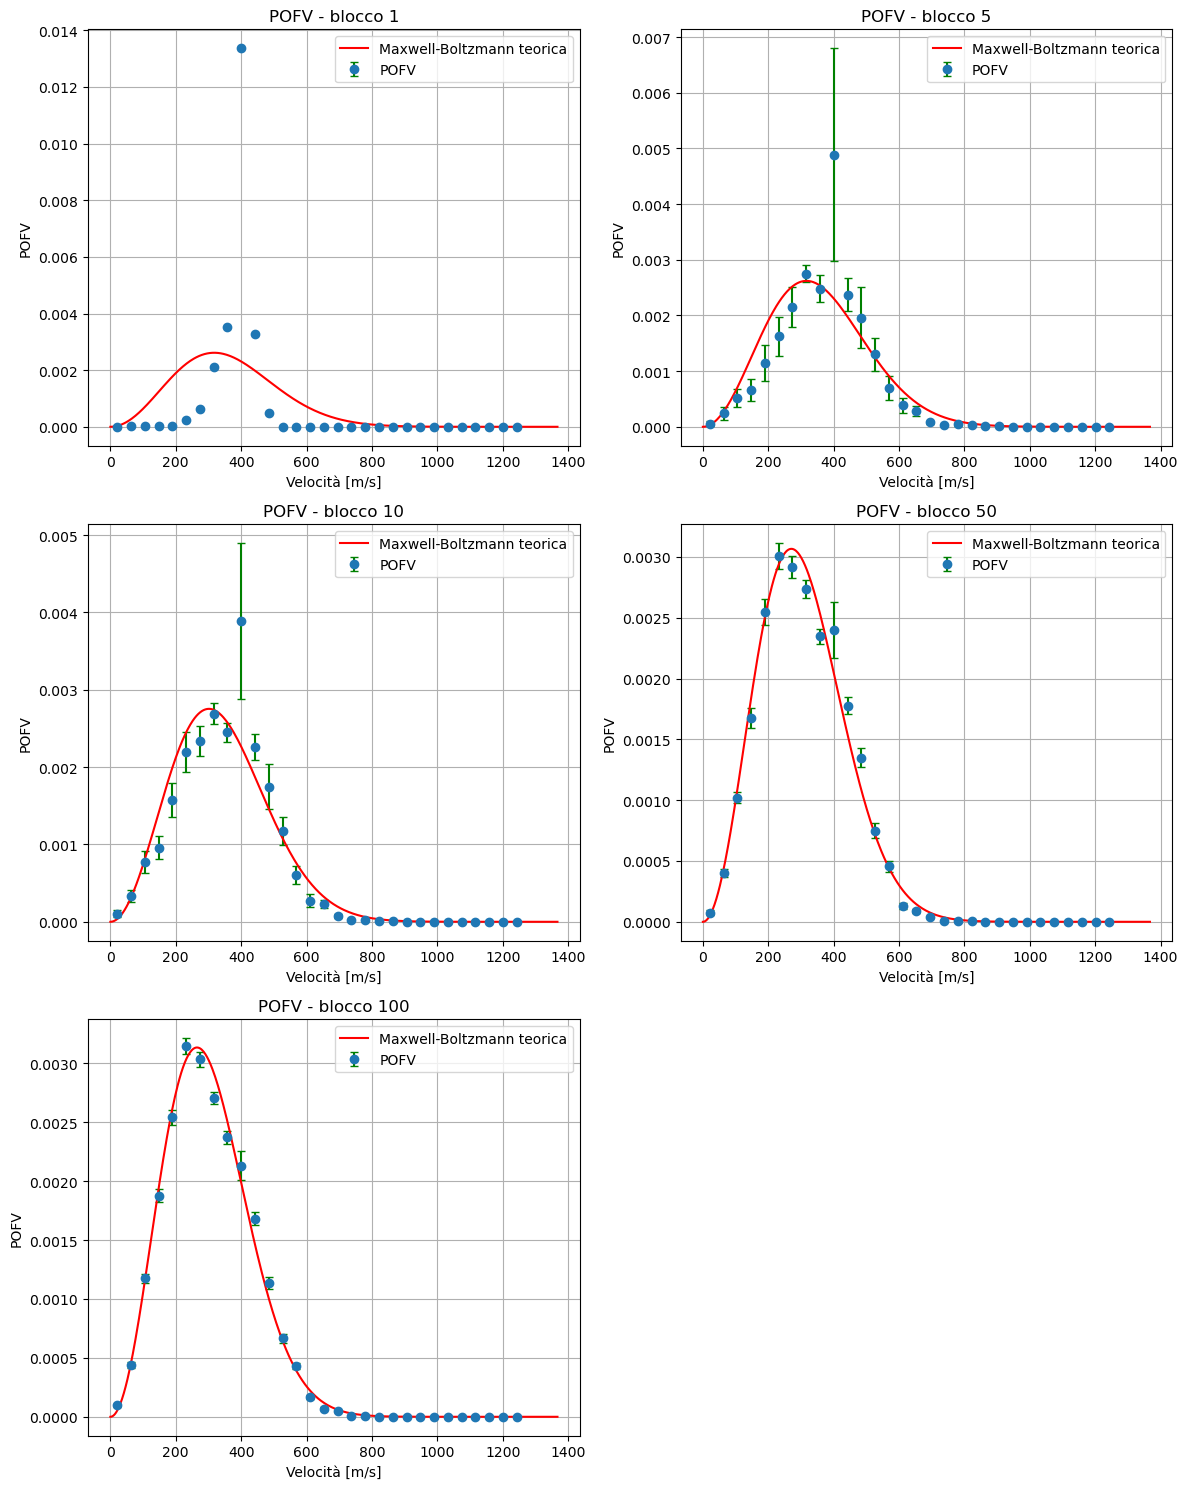

Integrale POFV simulata blocco 1: 1.0000050549844979
Integrale POFV simulata blocco 5: 1.0000012076429199
Integrale POFV simulata blocco 10: 1.00000081024628


In [3]:
import numpy as np
import matplotlib.pyplot as plt

blocco_size=30

T_1=2.01927 
T_5=2.00941
T_10=1.81981
T_50=1.46718
T_100=1.40488

data_2=np.loadtxt("NSL_SIMULATOR_4.2/RISULTATI/OUTPUT_100/pofv.dat")

#seleziono i dati relativi a ciascun blocco, ricordandomi che ho fatto stampare i blocchi uno dopo l'altro
blocco_1=data_2[0*blocco_size:1*blocco_size]
blocco_5=data_2[4*blocco_size:5*blocco_size]
blocco_10=data_2[9*blocco_size:10*blocco_size]
blocco_50=data_2[49*blocco_size:50*blocco_size]
blocco_100=data_2[99*blocco_size:100*blocco_size]

#stampo solo alcuni blocchi per mostrare andamento pofv
vel_1=blocco_1[:,0]
media_1=blocco_1[:,1]
errore_1=blocco_1[:,2]

vel_5=blocco_5[:,0]
media_5=blocco_5[:,1]
errore_5=blocco_5[:,2]

vel_10=blocco_10[:,0]
media_10=blocco_10[:,1]
errore_10=blocco_10[:,2]

vel_50=blocco_50[:,0]
media_50=blocco_50[:,1]
errore_50=blocco_50[:,2]

vel_100=blocco_100[:,0]
media_100=blocco_100[:,1]
errore_100=blocco_100[:,2]




#MB teoriche
v_theory_1 = np.linspace(0, max(vel_1)*1.1, 500)*v_norm  #genero 500 valori di velocità tra 0 e max(vel)*1.1 (così la curva toerica arriva un pochino oltre l'ultima velocità osservata)
P_MB_1 = MB_teorica(v_theory_1, massa, kB_value, T_1*e_kB) #chiamo sui vlaori di velocità generati prima la funzione di MB teorica (definita nell'eserciio prima)

v_theory_5 = np.linspace(0, max(vel_5)*1.1, 500)*v_norm
P_MB_5 = MB_teorica(v_theory_5, massa, kB_value, T_5*e_kB)

v_theory_10 = np.linspace(0, max(vel_10)*1.1, 500)*v_norm
P_MB_10 = MB_teorica(v_theory_10, massa, kB_value, T_10*e_kB)

v_theory_50 = np.linspace(0, max(vel_10)*1.1, 500)*v_norm
P_MB_50 = MB_teorica(v_theory_50, massa, kB_value, T_50*e_kB)

v_theory_100 = np.linspace(0, max(vel_10)*1.1, 500)*v_norm
P_MB_100 = MB_teorica(v_theory_100, massa, kB_value, T_100*e_kB)



plt.figure(figsize=(12,15))

plt.subplot(3,2,1)  #2 righe, 2 colonne, grafico del primo blocco
plt.errorbar(vel_1*v_norm, media_1/v_norm, yerr=errore_1/v_norm, fmt='o', ecolor='green', capsize=3, label="POFV")
plt.title("POFV - blocco 1")
plt.xlabel("Velocità [m/s]")
plt.ylabel("POFV")
plt.plot(v_theory_1, P_MB_1, 'r-', label="Maxwell-Boltzmann teorica")
plt.legend()
plt.grid(True)

plt.subplot(3,2,2)  #quinto blocco
plt.errorbar(vel_5*v_norm, media_5/v_norm, yerr=errore_5/v_norm, fmt='o', ecolor='green', capsize=3, label="POFV")
plt.title("POFV - blocco 5")
plt.xlabel("Velocità [m/s]")
plt.ylabel("POFV")
plt.plot(v_theory_5, P_MB_5, 'r-', label="Maxwell-Boltzmann teorica")
plt.legend()
plt.grid(True)

plt.subplot(3,2,3)  #Decimo blocco
plt.errorbar(vel_10*v_norm, media_10/v_norm, yerr=errore_10/v_norm, fmt='o', ecolor='green', capsize=3, label="POFV")
plt.title("POFV - blocco 10")
plt.xlabel("Velocità [m/s]")
plt.ylabel("POFV")
plt.plot(v_theory_10, P_MB_10, 'r-', label="Maxwell-Boltzmann teorica")
plt.legend()
plt.grid(True)

plt.subplot(3,2,4)  #ciqnuantesimo blocco
plt.errorbar(vel_50*v_norm, media_50/v_norm, yerr=errore_50/v_norm, fmt='o', ecolor='green', capsize=3, label="POFV")
plt.title("POFV - blocco 50")
plt.xlabel("Velocità [m/s]")
plt.ylabel("POFV")
plt.plot(v_theory_50, P_MB_50, 'r-', label="Maxwell-Boltzmann teorica")
plt.legend()
plt.grid(True)

plt.subplot(3,2,5)  #ultimo blocco
plt.errorbar(vel_100*v_norm, media_100/v_norm, yerr=errore_100/v_norm, fmt='o', ecolor='green', capsize=3, label="POFV")
plt.title("POFV - blocco 100")
plt.xlabel("Velocità [m/s]")
plt.ylabel("POFV")
plt.plot(v_theory_100, P_MB_100, 'r-', label="Maxwell-Boltzmann teorica")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




integrale1 = np.sum(media_1 * np.diff(vel_1, append=vel_1[-1] + (vel_1[1]-vel_1[0])))
print("Integrale POFV simulata blocco 1:", integrale1)

integrale5 = np.sum(media_5 * np.diff(vel_5, append=vel_5[-1] + (vel_5[1]-vel_5[0])))
print("Integrale POFV simulata blocco 5:", integrale5)

integrale10 = np.sum(media_10 * np.diff(vel_10, append=vel_10[-1] + (vel_10[1]-vel_10[0])))
print("Integrale POFV simulata blocco 10:", integrale10)



**COMMENTI AI RISULTATI**
1) Ho deciso di far girare la simulazione usando 100 blocchi da 100 steps ciascuno, anzichè 10 blocchi da 1000 steps l'uno. Infatti, considerando un numero di step per blocco troppo grande, non si riuscirebbe a vedere bene lo spostamento graduale di ciascun blocco verso l'equilibrio, dal momento che già il primo blocco verrebbe analizzato dopo un numero di step sufficienti ad avvicinarsi alla termalizzazione.
   
2) Noto che il picco della distribuzione impiega diversi blocchi a spostarsi verso valori più bassi, compatibili con la MB: questo riflette il fatto che il sistema parte da una condizione di velocità particolarmente lontana dall'equilibrio termodinamico, e da una configurazione spaziale compressa. Durante l'evoluzione dinamica, le interazioni tra le particelle e le collisioni redistribuiscono progressivamente l'energia tra i diversi gradi di libertà, facendo perdere memoria delle condizioni iniziali. Di conseguenza, il picco della distribuzione si abbassa e si allarga fino ad assumere la forma caratteristica della distribuzione di Maxwell–Boltzmann. Il tempo necessario per osservare questa convergenza può quindi essere interpretato come il tempo di rilassamento del sistema verso l'equilibrio termodinamico.

# **ESERCIZIO 4.3**

**OBIETTIVI**

L'obiettivo di questo esercizio è studiare il concetto di reversibilità temporale nelle leggi della dinamica microscopica, e osservare come si scontri con l'irreversibilità macroscopica. Infatti, le equazioni del moto sono invarianti per inversione temporale, ma macroscopicamente il sistema evolve verso stati a entropia maggiore (secondo principio della termodinamica).

In particolare, l'esercizio richiede due diverse simulazioni e un'analisi dei risultati ottenuti per quanto riguarda reversibilità di temperatura e energia potenziale:

1) **SIMULAZIONE IN AVANTI:** faccio girare il programma dell'esercizio 4.2 per 2 volte (con 5000 e con 50000 time steps, ovvero 10 blocchi rispettivamente da 500 e 5000 nsteps), salvando le configurazioni finali.
2) **INVERSIONE DEL TEMPO:** devo fare una simulazione "all'indietro", ovvero devo partire dalla configurazione *finale* del *punto 1)*. Poiché l'algoritmo di Verlet non utilizza direttamente le velocità ma le ricava dalle posizioni a tempi consecutivi, l'inversione delle velocità può essere ottenuta scambiando il ruolo delle configurazioni "old" e "new": in questo modo cambia il segno della velocità associata a ciascuna particella e la dinamica evolve all'indietro nel tempo.
3) **ANALISI:** analizzo i dati relativi a temperatura e energia potenziale.

**IMPLEMENTAZIONE**

1) INVERSIONE DEL TEMPO

   
    - modifico la riga di codice che mi dice dove trovare i file input, puntando alla cartella in cui ho salvato gli output della simulazione "in avanti": in questo modo, initialize utilizzerà le configurazioni finali della simulazione "in avanti" come punto di partenza.

   - imposto il parametro RESTART = 1, così da non generare nuove velocità ma da leggerle direttamente dai file indicati.

   - per invertire la direzione del moto, agisco sulle posizioni, dal momento che l'algoritmo di Verlet ricava le velocità dalla differenza tra posizione attuale e posizione precedente. 

   - in particolare, la nuova posizione "old" deve trovarsi in direzione opposta a quella originale: devo calcolare la "nuova" posizione "old" (ovvero la nuova posizione ma "all'indietro") usando i dati salvati in "config" e "conf-1".

   -  dal momento che voglio che il primo step di Verlet produca come nuova posizione quella che era la posizione "old" della simulazione "in avanti", impongo che:
  
       - $x_{old}$ venga letta da "config.xyz"
       - $x_{act}$ venga letta da "conf-1.xyz"

        In questo modo, ho invertito la direzione del moto: tramite Verlet, le particelle percorreranno le loro traiettorie a ritroso.


2) CONVERSIONE DELLE UNITA' DI MISURA

    Per poter plottare i dati nei grafici secondo i parametri dell'Argon, devo prima riconvertire le grandezze, che vengono stampate in unità ridotte, in unità di misura standard.


   - TEMPERATURA: $$T[K]=\frac{T^* \cdot \varepsilon}{k_B}$$

   - ENERGIA POTENZIALE: $$U \, [eV] = U^* \cdot \varepsilon[eV]$$

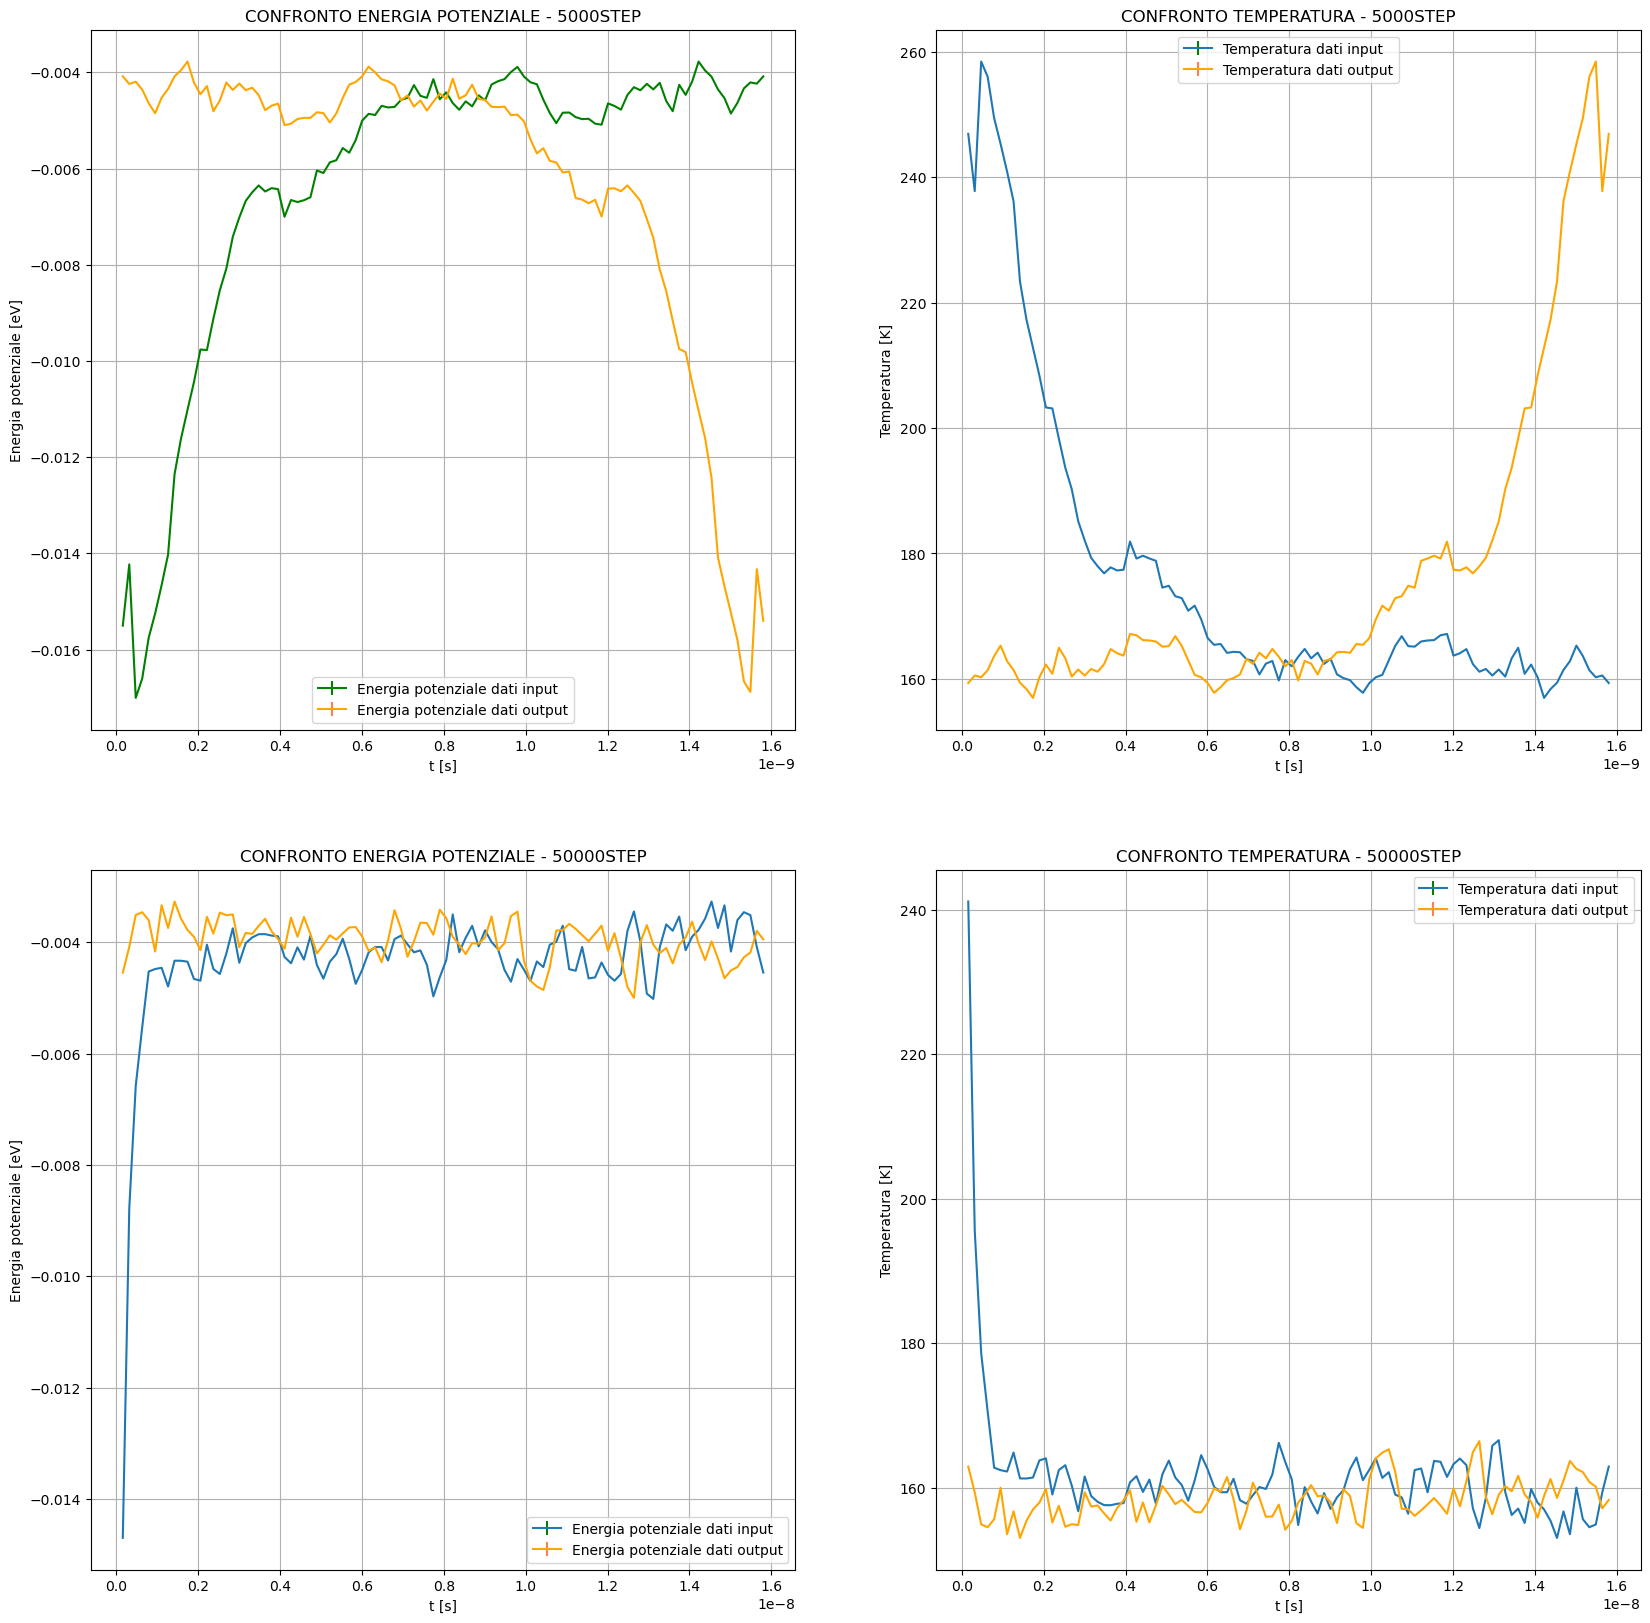

In [8]:
import numpy as np
import matplotlib.pyplot as plt

#indici blocchi
x=np.arange(100)

#passo temporale in unità ridotte
delta=0.002e-12

#normalizzazione
t_norm=delta*np.sqrt(e_kB*kB_value/massa)

########################################################################################################
#ENERGIA POTENZIALE
input_U_5000=np.loadtxt("NSL_SIMULATOR_4.3/RISULTATI/INPUT_5000/potential_energy.dat")*e_kB*kB_value/eV
input_U_50000=np.loadtxt("NSL_SIMULATOR_4.3/RISULTATI/INPUT_50000/potential_energy.dat")*e_kB*kB_value/eV
output_U_5000=np.loadtxt("NSL_SIMULATOR_4.3/RISULTATI/OUTPUT_5000/potential_energy.dat")*e_kB*kB_value/eV
output_U_50000=np.loadtxt("NSL_SIMULATOR_4.3/RISULTATI/OUTPUT_50000/potential_energy.dat")*e_kB*kB_value/eV

media_in_U_5000=input_U_5000[:,1]
media_in_U_50000=input_U_50000[:,1]
media_out_U_5000=output_U_5000[:,1]
media_out_U_50000=output_U_50000[:,1]

########################################################################################################
#TEMPERATURA
input_T_5000=np.loadtxt("NSL_SIMULATOR_4.3/RISULTATI/INPUT_5000/temperature.dat")*e_kB
input_T_50000=np.loadtxt("NSL_SIMULATOR_4.3/RISULTATI/INPUT_50000/temperature.dat")*e_kB
output_T_5000=np.loadtxt("NSL_SIMULATOR_4.3/RISULTATI/OUTPUT_5000/temperature.dat")*e_kB
output_T_50000=np.loadtxt("NSL_SIMULATOR_4.3/RISULTATI/OUTPUT_50000/temperature.dat")*e_kB

media_in_T_5000=input_T_5000[:,1]
media_in_T_50000=input_T_50000[:,1]
media_out_T_5000=output_T_5000[:,1]
media_out_T_50000=output_T_50000[:,1]

########################################################################################################


plt.figure(figsize=(20,20))

plt.subplot(2,2,1)
#moltiplico per 50 perchè ogni blocco contiene 50 steps (sto stampando in funzione del tempo)
plt.errorbar((x+1)*t_norm*50, media_in_U_5000, 0*errore_in_U_5000, color='green', label="Energia potenziale dati input")
plt.errorbar((x+1)*t_norm*50,media_out_U_5000, 0*errore_out_U_5000, color="orange", ecolor='coral', label="Energia potenziale dati output")
plt.title("CONFRONTO ENERGIA POTENZIALE - 5000STEP")
plt.xlabel("t [s]")
plt.ylabel("Energia potenziale [eV]")
plt.legend()
plt.grid(True)

plt.subplot(2,2,3)
plt.errorbar((x+1)*t_norm*500, media_in_U_50000, 0, ecolor='green', label="Energia potenziale dati input")
plt.errorbar((x+1)*t_norm*500,media_out_U_50000, 0, color="orange", ecolor='coral', label="Energia potenziale dati output")
plt.title("CONFRONTO ENERGIA POTENZIALE - 50000STEP")
plt.xlabel("t [s]")
plt.ylabel("Energia potenziale [eV]")
plt.legend()
plt.grid(True)

plt.subplot(2,2,2)
plt.errorbar((x+1)*50*t_norm, media_in_T_5000, 0,  ecolor='green', label="Temperatura dati input")
plt.errorbar((x+1)*t_norm*50,media_out_T_5000, 0, color="orange", ecolor='coral', label="Temperatura dati output")
plt.title("CONFRONTO TEMPERATURA - 5000STEP")
plt.xlabel("t [s]")
plt.ylabel("Temperatura [K]")
plt.legend()
plt.grid(True)

plt.subplot(2,2,4)
plt.errorbar((x+1)*t_norm*500, media_in_T_50000, 0,  ecolor='green', label="Temperatura dati input")
plt.errorbar((x+1)*t_norm*500,media_out_T_50000, 0, color="orange", ecolor='coral', label="Temperatura dati output")
plt.title("CONFRONTO TEMPERATURA - 50000STEP")
plt.xlabel("t [s]")
plt.ylabel("Temperatura [K]")
plt.legend()
plt.grid(True)
plt.show()


**COMMENTO AI RISULTATI**

I dati riportati nei grafici sono stati ottenuti con un numero di blocchi pari a 100 e di step per blocco pari a 50 e a 500 rispettivamente per la simulazione da 5 000 e da 50 000 steps totali. In particolare, si nota facilmente come la reversibilità sia preservata nel caso di 5 000 step, e sia invece rotta nel caso a 50 000 step. Questa discrepanza permette di studiare il comportamento di un sistema "a breve termine" (caso 5 000 step) e "a lungo termine" (caso 50 000 step). 

- 5 000 STEP (BREVE TERMINE): i grafici di temperatura e energia potenziale relativi a questa simulazione sono quasi perfettamente speculari, indice di una reversibilità temporale quasi perfetta.
- 50 000 STEP (LUNGO TERMINE): i grafici di temperatura e energia potenziale relativi a questa simulazione non sono speculari.

Quindi, all'aumentare del numero di step totali della simulazione si osserva una progressiva perdita della reversibilità. Questo è verosimilmente dovuto al fatto che con 5 000 step il sistema non ha avuto abbastanza tempo per esplorare lo spazio delle fasi ed è quindi ancora "vicino" alla configurazione iniziale, perciò invertendo le velocità riesce a tornare indietro. Al contratio, con 50 000 step il sistema ha verosimilmente raggiunto l'equilibrio termodinamico: a questo punto, lo stato è in una regione dello spazio delle fasi molto più probabile di quella iniziale, e invertendo le velocità è improbabile che il sistema torni indietro, per la seconda legge della termodinamica.